In [1]:
!pip install pandas numpy scikit-learn xgboost imbalanced-learn shap streamlit matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.9 MB/s eta 0:00:00


In [3]:
import pandas as pd

# Clean and working URL (limited to recent years to avoid timeout)
URL = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=300000&$where=year>=2022&$select=date,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,latitude,longitude"

# This encodes the URL properly
df = pd.read_csv(URL)

print(f"Shape: {df.shape}")
print(df.columns.tolist())
df.head()

Shape: (300000, 12)
['date', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'latitude', 'longitude']


,date,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,latitude,longitude
0,2026-05-17T00:00:00.000,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,1032,10,22.0,30.0,41.841960,-87.707405
1,2026-05-17T00:00:00.000,ASSAULT,SIMPLE,RESIDENCE,False,False,1111,11,28.0,25.0,41.894082,-87.744158
2,2026-05-17T00:00:00.000,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,1234,12,25.0,31.0,41.853959,-87.679505
3,2026-05-17T00:00:00.000,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1132,11,28.0,26.0,41.876137,-87.728831
4,2026-05-17T00:00:00.000,OTHER OFFENSE,HARASSMENT BY TELEPHONE,APARTMENT,False,False,1124,11,28.0,27.0,41.879665,-87.704654


In [4]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Crime types distribution (very important)
print("\nTop 15 Crime Types:")
print(df['primary_type'].value_counts().head(15))

# Date range
df['date'] = pd.to_datetime(df['date'])
print("\nDate Range:", df['date'].min(), "to", df['date'].max())

# Basic stats for latitude/longitude
print("\nLatitude stats:\n", df['latitude'].describe())
print("\nLongitude stats:\n", df['longitude'].describe())

Dataset Shape: (300000, 12)

Columns: ['date', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'latitude', 'longitude']

Missing Values:
 date                       0
primary_type               0
description                0
location_description    1440
arrest                     0
domestic                   0
beat                       0
district                   0
ward                       1
community_area            10
latitude                1443
longitude               1443
dtype: int64

Top 15 Crime Types:
primary_type
THEFT                         68644
BATTERY                       54410
CRIMINAL DAMAGE               33201
ASSAULT                       27348
MOTOR VEHICLE THEFT           22289
OTHER OFFENSE                 20955
DECEPTIVE PRACTICE            18468
BURGLARY                      13803
NARCOTICS                      9063
CRIMINAL TRESPASS              6916
ROBBERY                        6

In [21]:
# Always work on a copy so your original df stays untouched
# If you mess something up, you can re-run from here without re-downloading 300k rows
data = df.copy()

# Your df['date'] is already parsed from Cell 2, but let's ensure it on the copy
data['date'] = pd.to_datetime(data['date'])

# Drop rows where lat/lon is missing
# WHY? Our entire project is "predict risk at a LOCATION" — no location = useless row
print(f"Before cleaning: {len(data)} rows")
data = data.dropna(subset=['latitude', 'longitude'])
print(f"After dropping null lat/lon: {len(data)} rows")
print(f"Rows lost: {len(df) - len(data)} ({(len(df)-len(data))/len(df)*100:.2f}%)")

Before cleaning: 300000 rows
After dropping null lat/lon: 298557 rows
Rows lost: 1443 (0.48%)


In [22]:
# HOUR: Which hour of the day did this crime happen?
# This is our single most powerful feature for risk prediction
# Think about it — crime at 3 AM vs 3 PM is very different
data['hour'] = data['date'].dt.hour

# DAY OF WEEK: 0=Monday, 1=Tuesday, ..., 6=Sunday
# Weekday vs weekend crime patterns differ (bars close late on weekends, etc.)
data['day_of_week'] = data['date'].dt.dayofweek

# MONTH: Captures seasonal patterns
# Chicago winters are brutal — fewer people outside = different crime patterns
data['month'] = data['date'].dt.month

# IS_WEEKEND: Binary flag — sometimes simpler features work better than raw day numbers
# XGBoost CAN learn "5 and 6 are similar" from day_of_week, but why make it harder?
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

# Verify everything looks right
print(data[['date', 'hour', 'day_of_week', 'month', 'is_weekend']].head(10))
print(f"\nHour range: {data['hour'].min()} to {data['hour'].max()}")
print(f"Day range: {data['day_of_week'].min()} to {data['day_of_week'].max()}")
print(f"Month range: {data['month'].min()} to {data['month'].max()}")
print(f"Weekend split:\n{data['is_weekend'].value_counts()}")

        date  hour  day_of_week  month  is_weekend
0 2026-05-17     0            6      5           1
1 2026-05-17     0            6      5           1
2 2026-05-17     0            6      5           1
3 2026-05-17     0            6      5           1
4 2026-05-17     0            6      5           1
5 2026-05-17     0            6      5           1
6 2026-05-17     0            6      5           1
7 2026-05-17     0            6      5           1
8 2026-05-17     0            6      5           1
9 2026-05-17     0            6      5           1

Hour range: 0 to 23
Day range: 0 to 6
Month range: 1 to 12
Weekend split:
is_weekend
0    212462
1     86095
Name: count, dtype: int64


In [23]:
# Before we plot, let's just look at raw numbers
# This builds your intuition for what the plots SHOULD look like

# Which hours have the most crime?
print("Top 5 hours by crime count:")
print(data['hour'].value_counts().head(5))

print("\nBottom 5 hours by crime count:")
print(data['hour'].value_counts().tail(5))

# Weekend vs weekday
print(f"\nWeekday crimes: {len(data[data['is_weekend']==0])}")
print(f"Weekend crimes: {len(data[data['is_weekend']==1])}")
print(f"Ratio (weekday has 5 days, weekend has 2):")
weekday_per_day = len(data[data['is_weekend']==0]) / 5
weekend_per_day = len(data[data['is_weekend']==1]) / 2
print(f"  Per-day weekday: {weekday_per_day:.0f}")
print(f"  Per-day weekend: {weekend_per_day:.0f}")

Top 5 hours by crime count:
hour
0     19868
12    17097
15    16417
16    16191
17    15960
Name: count, dtype: int64

Bottom 5 hours by crime count:
hour
7    7889
3    7804
4    6296
6    6075
5    5470
Name: count, dtype: int64

Weekday crimes: 212462
Weekend crimes: 86095
Ratio (weekday has 5 days, weekend has 2):
  Per-day weekday: 42492
  Per-day weekend: 43048


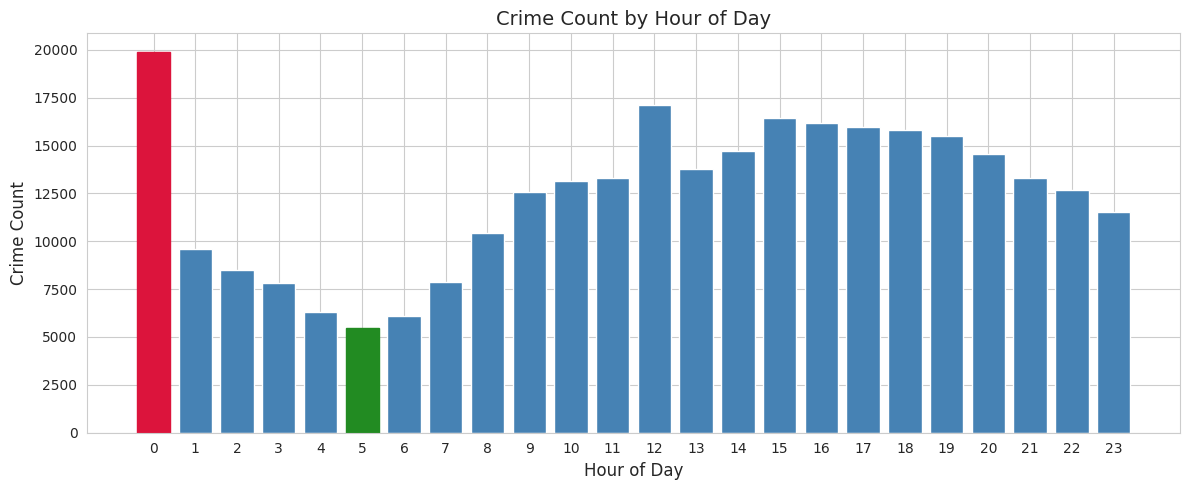

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))

hourly = data.groupby('hour').size()
bars = ax.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')

# Highlight the peak hour and lowest hour in different colors
bars[0].set_color('crimson')       # hour 0 = peak
bars[5].set_color('forestgreen')   # hour 5 = lowest

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Crime Count by Hour of Day', fontsize=14)
ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

# YOUR OBSERVATION (write this as understanding):
# Notice the bimodal pattern: midnight spike + afternoon plateau
# Crime drops sharply from 1AM-5AM (people sleeping)
# This tells us HOUR will be a strong feature for our model

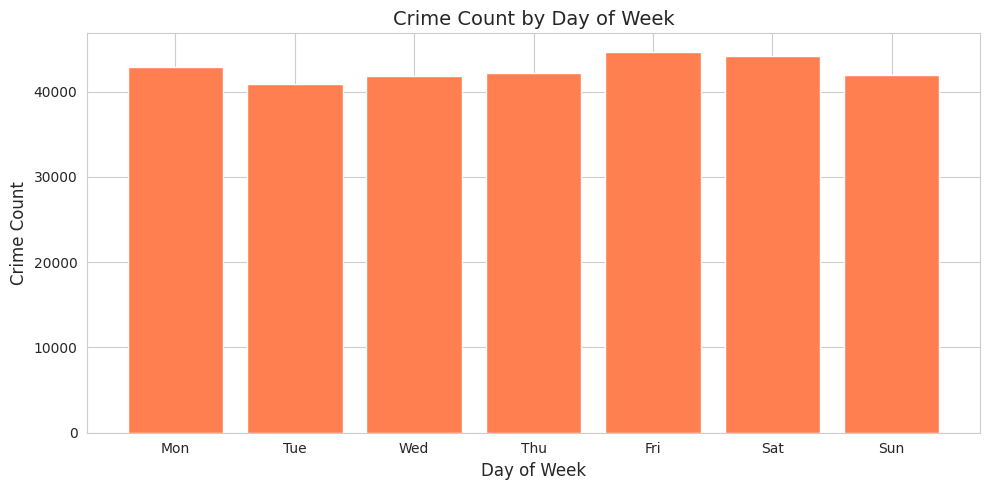

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = data.groupby('day_of_week').size()

bars = ax.bar(daily.index, daily.values, color='coral', edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Crime Count by Day of Week', fontsize=14)

plt.tight_layout()
plt.show()

# YOUR OBSERVATION:
# The bars should look fairly even (confirming our per-day calculation)
# Friday might be slightly higher — transition into weekend nightlife

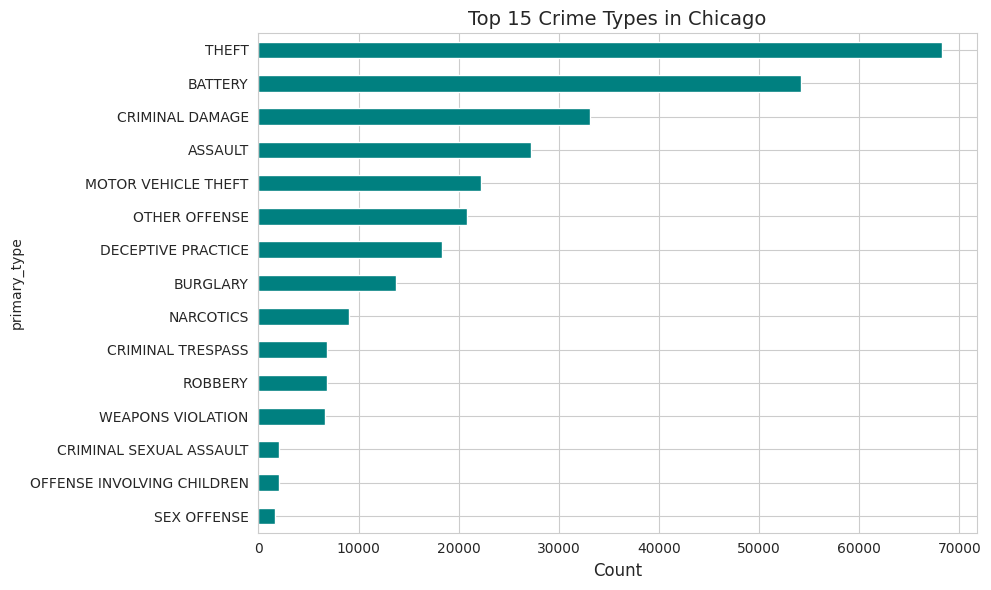

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

crime_counts = data['primary_type'].value_counts().head(15)
crime_counts.plot(kind='barh', ax=ax, color='teal', edgecolor='white')

ax.set_xlabel('Count', fontsize=12)
ax.set_title('Top 15 Crime Types in Chicago', fontsize=14)
ax.invert_yaxis()  # Highest on top

plt.tight_layout()
plt.show()

# YOUR OBSERVATION:
# THEFT dominates (~68k), then BATTERY (~54k), CRIMINAL DAMAGE (~33k)
# These top 3 make up over half the dataset
# HOMICIDE is NOT in top 15 — violent crimes are rare (this is the class imbalance problem)

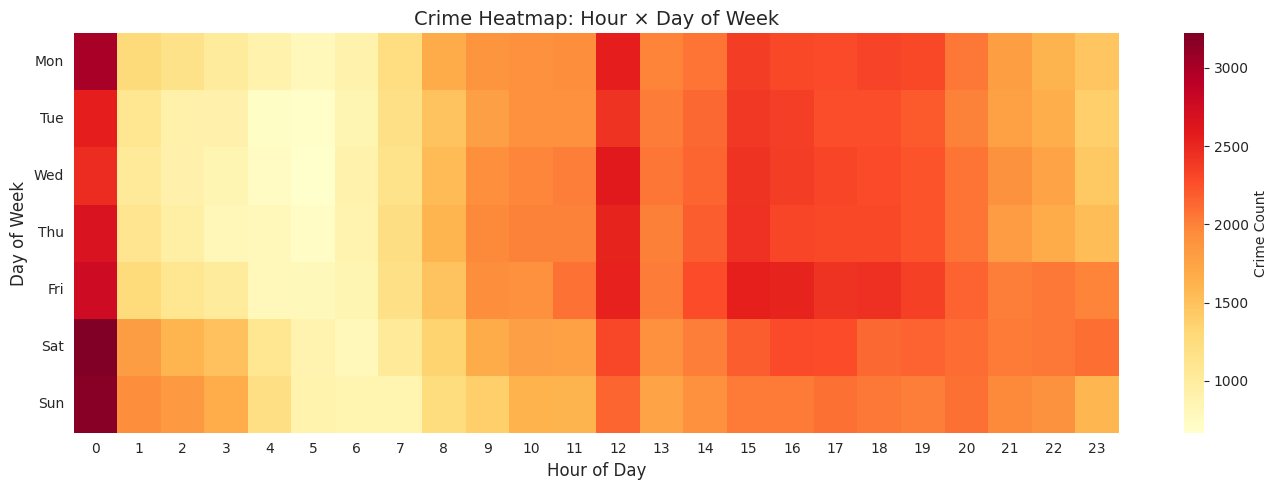

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

# Create a pivot: rows = day_of_week, columns = hour, values = crime count
pivot = data.pivot_table(
    index='day_of_week',
    columns='hour',
    values='date',        # any column works, we're just counting rows
    aggfunc='count'
)

sns.heatmap(
    pivot,
    cmap='YlOrRd',       # Yellow=low, Red=high
    annot=False,          # Too many cells for numbers
    cbar_kws={'label': 'Crime Count'},
    ax=ax
)

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax.set_yticklabels(dow_labels, rotation=0)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_title('Crime Heatmap: Hour × Day of Week', fontsize=14)

plt.tight_layout()
plt.show()

# YOUR OBSERVATION:
# Look for the RED cells — those are your "High Risk" time slots
# You should see Saturday-Sunday midnight area lighting up
# Early morning (3-6 AM) should be yellow across all days
# THIS is exactly what our model needs to learn

In [28]:
# We need to divide Chicago into a grid of location cells
# Rounding lat/lon to 2 decimal places gives us ~1km x 0.85km cells
# WHY 2 decimals?
#   - 1 decimal = ~11km cells (too coarse, entire neighborhoods lumped together)
#   - 2 decimals = ~1km cells (good balance — neighborhood-level granularity)
#   - 3 decimals = ~100m cells (too fine, most cells would have 0-1 crimes)

GRID_PRECISION = 2

data['lat_bin'] = data['latitude'].round(GRID_PRECISION)
data['lon_bin'] = data['longitude'].round(GRID_PRECISION)

# How many unique grid cells do we get?
data['grid_cell'] = data['lat_bin'].astype(str) + '_' + data['lon_bin'].astype(str)
print(f"Unique grid cells: {data['grid_cell'].nunique()}")

# Let's see the distribution — how many crimes per cell?
cell_counts = data['grid_cell'].value_counts()
print(f"\nCrimes per grid cell:")
print(cell_counts.describe())
print(f"\nTop 5 hotspot cells:")
print(cell_counts.head(5))
print(f"\nBottom 5 cells:")
print(cell_counts.tail(5))

Unique grid cells: 719

Crimes per grid cell:
count     719.000000
mean      415.239221
std       472.546283
min         1.000000
25%        80.000000
50%       295.000000
75%       596.500000
max      5515.000000
Name: count, dtype: float64

Top 5 hotspot cells:
grid_cell
41.89_-87.63    5515
41.88_-87.63    4743
41.9_-87.63     2855
41.89_-87.62    2556
41.87_-87.63    2249
Name: count, dtype: int64

Bottom 5 cells:
grid_cell
41.77_-87.77    1
41.94_-87.63    1
41.97_-87.92    1
41.68_-87.7     1
41.83_-87.74    1
Name: count, dtype: int64


In [29]:
# NOW the key step: group by (grid_cell, hour, day_of_week) and COUNT crimes
# Each row in this new dataframe represents:
#   "In grid cell X, at hour Y, on day-of-week Z, there were N crimes"

agg = (
    data.groupby(['grid_cell', 'lat_bin', 'lon_bin', 'hour', 'day_of_week'])
    .agg(
        crime_count=('date', 'size'),                    # how many crimes in this bin
        n_crime_types=('primary_type', 'nunique'),       # diversity of crime types
        month_mode=('month', lambda x: x.mode().iloc[0]) # most common month (seasonal signal)
    )
    .reset_index()
)

# Add is_weekend back (derived from day_of_week)
agg['is_weekend'] = agg['day_of_week'].isin([5, 6]).astype(int)

print(f"Original event-level rows: {len(data)}")
print(f"Aggregated bin-level rows: {len(agg)}")
print(f"\ncrime_count distribution:")
print(agg['crime_count'].describe())

Original event-level rows: 298557
Aggregated bin-level rows: 78494

crime_count distribution:
count    78494.000000
mean         3.803565
std          3.830177
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         93.000000
Name: crime_count, dtype: float64


In [30]:
# Use quantile-based binning (qcut) to create 3 roughly equal-sized classes
# WHY qcut instead of fixed thresholds?
#   - Fixed thresholds (like "1-5 = Low, 6-20 = Medium, 20+ = High") are arbitrary
#   - qcut splits based on the actual data distribution
#   - This gives us balanced classes, which means the model has enough examples of each

agg['risk_level'] = pd.qcut(
    agg['crime_count'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'  # handles edge cases where quantile boundaries overlap
)

print("Target distribution:")
print(agg['risk_level'].value_counts())
print(f"\nPercentage:")
print(agg['risk_level'].value_counts(normalize=True) * 100)

# Let's also see what crime_count ranges each level covers
print(f"\nCrime count ranges per risk level:")
for level in ['Low', 'Medium', 'High']:
    subset = agg[agg['risk_level'] == level]['crime_count']
    print(f"  {level}: {subset.min()} to {subset.max()} crimes per bin")

Target distribution:
risk_level
Low       36981
High      22271
Medium    19242
Name: count, dtype: int64

Percentage:
risk_level
Low       47.113155
High      28.372869
Medium    24.513976
Name: proportion, dtype: float64

Crime count ranges per risk level:
  Low: 1 to 2 crimes per bin
  Medium: 3 to 4 crimes per bin
  High: 5 to 93 crimes per bin


In [31]:
# Cross-check with our heatmap intuition
# Saturday (5) at midnight (0) should lean toward High risk
# Tuesday (1) at 5 AM should lean toward Low risk

print("Risk level breakdown for Saturday midnight (hour=0, dow=5):")
sat_midnight = agg[(agg['hour'] == 0) & (agg['day_of_week'] == 5)]
print(sat_midnight['risk_level'].value_counts())

print("\nRisk level breakdown for Tuesday 5AM (hour=5, dow=1):")
tue_5am = agg[(agg['hour'] == 5) & (agg['day_of_week'] == 1)]
print(tue_5am['risk_level'].value_counts())

# If Saturday midnight has more "High" and Tuesday 5AM has more "Low",
# our target variable is well-constructed

Risk level breakdown for Saturday midnight (hour=0, dow=5):
risk_level
High      267
Low       176
Medium    112
Name: count, dtype: int64

Risk level breakdown for Tuesday 5AM (hour=5, dow=1):
risk_level
Low       254
Medium     69
High       24
Name: count, dtype: int64


In [32]:
# Save so we can use it in a separate modeling notebook later
agg.to_csv('crime_risk_aggregated.csv', index=False)
print(f"Saved: crime_risk_aggregated.csv ({len(agg)} rows)")

# Let's look at what we have — these are our candidate features
print("\nColumns in aggregated data:")
print(agg.columns.tolist())
print(f"\nFirst 5 rows:")
agg.head()

Saved: crime_risk_aggregated.csv (78494 rows)

Columns in aggregated data:
['grid_cell', 'lat_bin', 'lon_bin', 'hour', 'day_of_week', 'crime_count', 'n_crime_types', 'month_mode', 'is_weekend', 'risk_level']

First 5 rows:


,grid_cell,lat_bin,lon_bin,hour,day_of_week,crime_count,n_crime_types,month_mode,is_weekend,risk_level
0,41.64_-87.54,41.64,-87.54,8,0,1,1,4,0,Low
1,41.64_-87.54,41.64,-87.54,15,1,1,1,11,0,Low
2,41.64_-87.54,41.64,-87.54,16,2,1,1,6,0,Low
3,41.64_-87.6,41.64,-87.60,13,1,1,1,5,0,Low
4,41.64_-87.6,41.64,-87.60,23,5,1,1,6,1,Low


In [33]:
# THINK ABOUT INFERENCE TIME:
# A user opens your app and enters: lat=41.85, lon=-87.65, hour=22, day=Saturday
# Your model must predict: Low, Medium, or High
#
# So the features must be things you KNOW at query time:
#   ✅ lat_bin, lon_bin    → user provides location
#   ✅ hour               → user provides time
#   ✅ day_of_week        → user provides day
#   ✅ is_weekend         → derived from day_of_week
#
# What about n_crime_types and month_mode?
#   These come from HISTORICAL data — you can't know them at query time
#   for a brand new (location, hour, day) combo.
#   BUT: for grid cells that exist in training data, you CAN look them up.
#   This is a design choice. For simplicity, we'll skip them for now
#   and add them as improvements later if needed.
#
# FEATURES WE'LL USE:
features = ['lat_bin', 'lon_bin', 'hour', 'day_of_week', 'is_weekend']

# TARGET:
target = 'risk_level'

print("Feature matrix shape:", agg[features].shape)
print("\nFeature types:")
print(agg[features].dtypes)
print("\nTarget distribution:")
print(agg[target].value_counts())
print("\nSample rows (features + target):")
agg[features + [target]].sample(10, random_state=42)

Feature matrix shape: (78494, 5)

Feature types:
lat_bin        float64
lon_bin        float64
hour             int32
day_of_week      int32
is_weekend       int64
dtype: object

Target distribution:
risk_level
Low       36981
High      22271
Medium    19242
Name: count, dtype: int64

Sample rows (features + target):


,lat_bin,lon_bin,hour,day_of_week,is_weekend,risk_level
69653,41.98,-87.69,20,5,1,High
17834,41.76,-87.63,11,5,1,Medium
33929,41.82,-87.72,18,0,0,Medium
17749,41.76,-87.62,23,0,0,High
57973,41.93,-87.72,23,1,0,Low
56026,41.92,-87.77,10,5,1,Medium
46811,41.89,-87.65,21,2,0,High
6391,41.71,-87.66,5,5,1,Medium
58454,41.93,-87.76,8,6,1,Medium
65002,41.96,-87.68,9,4,0,Low


In [37]:
%cd /content
!git clone https://github.com/DivyamAwasthy/chicago-crime-risk-predictor.git

/content
Cloning into 'chicago-crime-risk-predictor'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [38]:
%cd /content/chicago-crime-risk-predictor
!pwd
!git status

/content/chicago-crime-risk-predictor
/content/chicago-crime-risk-predictor
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [42]:
# [git push command removed for security]


In [43]:
# Find where the notebook actually is
!find /content -name "*.ipynb" 2>/dev/null